In [2]:
import polars as pl
import os
import json
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]  # Fast_Data_Discovery
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

exp_path = NOTEBOOK_DIR / 'logs'
exp_dir = os.listdir(exp_path)
runtime_res = {}
for exp in exp_dir:
    if not os.path.isdir(exp_path / exp):
        continue
    comb_log = exp_path / exp / f'{exp}.log'
    with open(comb_log) as f:
        lines = f.readlines()
    for i in range(len(lines)):
        lines[i] = json.loads(lines[i])
    df = pl.from_records(lines, orient='col')
    runtime = df.select(pl.col('runtime').sum()).to_series()[0]
    runtime_res[exp] = runtime
runtime_df = pl.from_dicts([{'experiment': k, 'runtime': v} for k, v in runtime_res.items()])
runtime_df = runtime_df.with_columns(
    pl.col('experiment').str.split('_').list.to_struct(upper_bound=3, fields=['lake', 'table', 'n_cores']).struct.unnest()
)

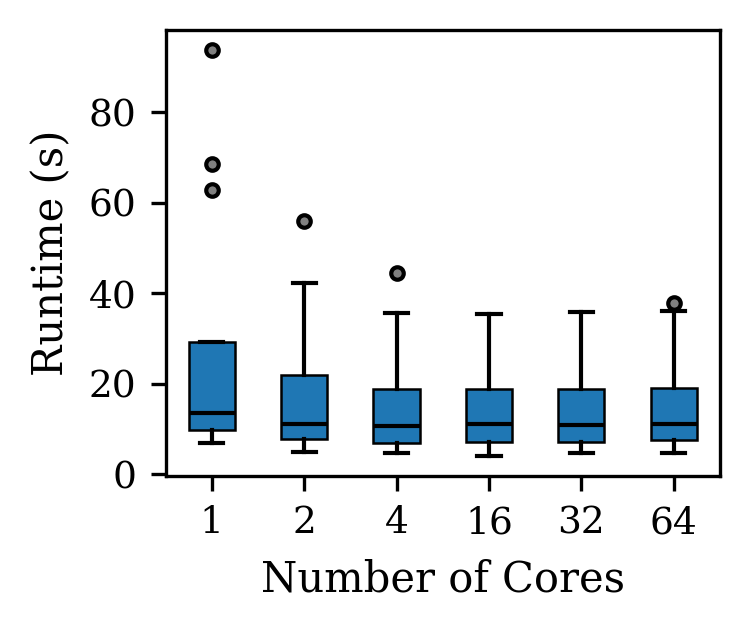

In [3]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
import plots_style
plots_style.apply_style()

BLUE = '#1f77b4'  # RGB(31,119,180) — same as full_incremental barblue

plot_df = runtime_df.with_columns(pl.col('n_cores').cast(pl.Int32)).sort('n_cores')
core_values = sorted(plot_df['n_cores'].unique().to_list())

# Prepare data for boxplot: list of runtime arrays, one per n_cores
box_data = [plot_df.filter(pl.col('n_cores') == c)['runtime'].to_list() for c in core_values]

fig, ax = plt.subplots(figsize=(2.4, 2.0))
bp = ax.boxplot(box_data, positions=range(len(core_values)), widths=0.5,
                patch_artist=True, showfliers=True,
                medianprops=dict(color='black', linewidth=1),
                flierprops=dict(marker='o', markersize=3, markerfacecolor='gray'))
for patch in bp['boxes']:
    patch.set_facecolor(BLUE)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)

# ax.set_yscale('log')
ax.set_xticks(range(len(core_values)))
ax.set_xticklabels([str(c) for c in core_values])
ax.set_xlabel('Number of Cores')
ax.set_ylabel('Runtime (s)')
plt.tight_layout(pad=0.3)
plt.savefig(PAPER_ROOT / 'figures' / 'n_jobs_ablation.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

In [4]:
import numpy as np

plot_df = runtime_df.with_columns(pl.col('n_cores').cast(pl.Int32)).sort('n_cores')
core_values = sorted(plot_df['n_cores'].unique().to_list())

# Build TikZ boxplot from data
tikz = [
    r"\definecolor{boxblue}{RGB}{31,119,180}",
    r"\begin{tikzpicture}",
    r"\begin{axis}[",
    r"  width=2.4in,",
    r"  height=2.0in,",
    r"  boxplot/draw direction=y,",
    r"  ylabel={Runtime (s)},",
    r"  xlabel={Number of Cores},",
    f"  xtick={{{','.join(str(i+1) for i in range(len(core_values)))}}},",
    f"  xticklabels={{{','.join(str(c) for c in core_values)}}},",
    r"  x tick label style={font=\small},",
    r"  y tick label style={font=\small},",
    r"  label style={font=\small},",
    r"  axis lines=left,",
    r"  enlarge x limits=0.12,",
    r"  ymin=0,",
    r"]",
]

for i, c in enumerate(core_values):
    vals = plot_df.filter(pl.col('n_cores') == c)['runtime'].to_list()
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    wlo = max(min(vals), q1 - 1.5 * iqr)
    whi = min(max(vals), q3 + 1.5 * iqr)
    outliers = [v for v in vals if v < wlo or v > whi]

    tikz.append(f"% n_cores = {c}")
    tikz.append(r"\addplot+[boxplot prepared={")
    tikz.append(f"    lower whisker={wlo:.1f}, lower quartile={q1:.1f},")
    tikz.append(f"    median={med:.1f},")
    tikz.append(f"    upper quartile={q3:.1f}, upper whisker={whi:.1f}}},")
    tikz.append(r"  fill=boxblue, draw=black, solid,")
    tikz.append(r"  every box/.style={line width=0.6pt},")
    tikz.append(r"  every median/.style={line width=1pt, black},")
    tikz.append(r"  every whisker/.style={line width=0.6pt},")
    tikz.append(r"  mark=o, mark options={scale=0.6, fill=gray, draw=black},")
    if outliers:
        coords = " ".join(f"({i+1},{v:.1f})" for v in outliers)
        tikz.append(f"] coordinates {{{coords}}};")
    else:
        tikz.append(r"] coordinates {};")
    tikz.append("")

tikz.append(r"\end{axis}")
tikz.append(r"\end{tikzpicture}")

tikz_code = "\n".join(tikz)
out_path = PAPER_ROOT / 'figures' / 'n_jobs_ablation.tex'
out_path.write_text(tikz_code)
print(f"Written to {out_path}")

Written to /home/fedor/Matryoshka/figures/n_jobs_ablation.tex
